# Proyek Analisis Data: E-Commerce Public Dataset (Olist Brazil)
- **Nama:** Fadli Nur Rofik
- **Email:** fadli.nurofik@gmail.com
- **ID Dicoding:** fadli_nur_rofik

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memperoleh informasi yang mendalam.

* **Spesific (Spesifik)** — pertanyaan fokus pada satu topik tertentu, tidak bermakna ganda.
* **Measurable (Terukur)** — dapat dijawab dengan angka/metrik konkret.
* **Action-Oriented (Berorientasi Aksi)** — hasilnya memberi arahan tindakan nyata bagi stakeholder.
* **Relevant (Relevan)** — sejalan dengan tujuan bisnis/masalah yang dihadapi.
* **Time-bound (Terikat Waktu)** — ada batasan waktu yang jelas.

- **Pertanyaan 1:** Kategori produk apa yang memberikan kontribusi *revenue* tertinggi dan terendah bagi platform selama periode data yang tersedia (2016–2018), sehingga tim bisnis dapat menentukan prioritas strategi promosi per kategori?
- **Pertanyaan 2:** Bagaimana rata-rata waktu pengiriman (dari pembelian hingga diterima pelanggan) di tiap provinsi (state) pelanggan selama 2016–2018, dan apakah keterlambatan pengiriman berkorelasi dengan *review score* yang lebih rendah, sehingga tim logistik dapat memprioritaskan perbaikan di wilayah tersebut?
- **Pertanyaan 3 (Analisis Lanjutan):** Bagaimana segmentasi pelanggan berdasarkan RFM (*Recency, Frequency, Monetary*) hingga akhir periode data (Agustus 2018), dan segmen mana yang perlu diprioritaskan untuk kampanye retensi?

## Import Semua Packages/Library yang Digunakan

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

# palet warna konsisten: abu-abu netral untuk kategori biasa,
# warna aksen untuk menyorot nilai tertinggi/terendah/penting
COLOR_NEUTRAL = "#b0b0b0"
COLOR_HIGH = "#2a9d8f"
COLOR_LOW = "#e76f51"
COLOR_HIGHLIGHT = "#264653"

print("Library siap digunakan.")

Library siap digunakan.


## Data Wrangling

### Gathering Data

#### Load seluruh dataset mentah (raw) E-Commerce Public Dataset

In [4]:
path = "data/"

customers_df = pd.read_csv(path + "customers_dataset.csv")
geolocation_df = pd.read_csv(path + "geolocation_dataset.csv")
order_items_df = pd.read_csv(path + "order_items_dataset.csv")
order_payments_df = pd.read_csv(path + "order_payments_dataset.csv")
order_reviews_df = pd.read_csv(path + "order_reviews_dataset.csv")
orders_df = pd.read_csv(path + "orders_dataset.csv")
product_category_df = pd.read_csv(path + "product_category_name_translation.csv")
products_df = pd.read_csv(path + "products_dataset.csv")
sellers_df = pd.read_csv(path + "sellers_dataset.csv")

for name, df in [("customers", customers_df), ("geolocation", geolocation_df),
                  ("order_items", order_items_df), ("order_payments", order_payments_df),
                  ("order_reviews", order_reviews_df), ("orders", orders_df),
                  ("product_category", product_category_df), ("products", products_df),
                  ("sellers", sellers_df)]:
    print(f"{name:20s}: {df.shape}")

customers           : (99441, 5)
geolocation         : (1000163, 5)
order_items         : (112650, 7)
order_payments      : (103886, 5)
order_reviews       : (99224, 7)
orders              : (99441, 8)
product_category    : (71, 2)
products            : (32951, 9)
sellers             : (3095, 4)


In [5]:
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


**Insight:**
- Dataset terdiri dari 9 tabel terpisah (customers, orders, order_items, order_payments, order_reviews, products, product_category_name_translation, sellers, geolocation) yang saling terhubung melalui `order_id`, `customer_id`, `product_id`, dan `seller_id`.
- Diperlukan proses penggabungan (merge) sebelum dapat menjawab pertanyaan bisnis.

### Assessing Data

#### Identifying missing value, invalid value, duplicate data, dan tipe data yang belum sesuai

In [6]:
print("=== orders_df info ===")
orders_df.info()
print("\nMissing value orders_df:\n", orders_df.isna().sum())
print("\nJumlah duplikat orders_df:", orders_df.duplicated().sum())

=== orders_df info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB

Missing value orders_df:
 order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrie

In [7]:
print("=== products_df ===")
print("Missing value:\n", products_df.isna().sum())
print("\nJumlah duplikat:", products_df.duplicated().sum())

=== products_df ===
Missing value:
 product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

Jumlah duplikat: 0


In [8]:
print("=== order_reviews_df ===")
print("Missing value:\n", order_reviews_df.isna().sum())
print("\nDistribusi review_score:\n", order_reviews_df['review_score'].value_counts().sort_index())

=== order_reviews_df ===
Missing value:
 review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

Distribusi review_score:
 review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64


In [9]:
for name, df in [("customers", customers_df), ("order_items", order_items_df),
                  ("order_payments", order_payments_df), ("sellers", sellers_df),
                  ("product_category", product_category_df)]:
    print(f"{name}: duplikat = {df.duplicated().sum()}, missing = {df.isna().sum().sum()}")

customers: duplikat = 0, missing = 0
order_items: duplikat = 0, missing = 0
order_payments: duplikat = 0, missing = 0
sellers: duplikat = 0, missing = 0
product_category: duplikat = 0, missing = 0


In [10]:
print(orders_df['order_status'].value_counts())
print("\nRentang tanggal order_purchase_timestamp:")
print(pd.to_datetime(orders_df['order_purchase_timestamp']).min(), "s/d",
      pd.to_datetime(orders_df['order_purchase_timestamp']).max())

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Rentang tanggal order_purchase_timestamp:
2016-09-04 21:15:19 s/d 2018-10-17 17:30:18


**Steps to Take:**
- Kolom bertipe tanggal pada `orders_df` (`order_purchase_timestamp`, `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date`, `order_estimated_delivery_date`) masih bertipe `object`, perlu dikonversi ke `datetime`.
- Missing value pada `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date` bersifat wajar (order belum sampai tahap tersebut, misal masih `shipped`/`canceled`) sehingga dibiarkan sebagai `NaT`, bukan dihapus.
- Missing value `product_category_name` pada `products_df` (610 baris) diisi dengan label `"unknown"` agar produk tetap bisa dianalisis tanpa mengurangi jumlah data.
- Missing value pada `order_reviews_df` (`review_comment_title`, `review_comment_message`) bersifat wajar karena komentar teks bersifat opsional bagi pelanggan, sehingga dibiarkan dan tidak memengaruhi kolom `review_score` yang akan digunakan.
- Tidak ditemukan data duplikat pada seluruh tabel.

**Insight:** (Opsional)
- Order dengan status `delivered` mendominasi (96.478 dari 99.441 order, ±97%), sehingga analisis performa penjualan difokuskan pada order berstatus `delivered` agar mencerminkan transaksi yang benar-benar selesai.
- Data mencakup periode September 2016 hingga Oktober 2018, namun volume transaksi baru stabil mulai awal 2017.

### Cleaning Data

#### Fixing tipe data tanggal dan missing value

In [11]:
date_cols = ["order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date",
             "order_delivered_customer_date", "order_estimated_delivery_date"]
for col in date_cols:
    orders_df[col] = pd.to_datetime(orders_df[col])

products_df["product_category_name"] = products_df["product_category_name"].fillna("unknown")
products_df = products_df.merge(product_category_df, on="product_category_name", how="left")
products_df["product_category_name_english"] = products_df["product_category_name_english"].fillna("unknown")

numeric_cols = ["product_weight_g", "product_length_cm", "product_height_cm", "product_width_cm"]
for col in numeric_cols:
    products_df[col] = products_df[col].fillna(products_df[col].median())

order_reviews_df = order_reviews_df.drop_duplicates(subset="review_id")

print("orders_df dtypes setelah cleaning:")
print(orders_df[date_cols].dtypes)
print("\nSisa missing value products_df:\n", products_df.isna().sum())

orders_df dtypes setelah cleaning:
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

Sisa missing value products_df:
 product_id                         0
product_category_name              0
product_name_lenght              610
product_description_lenght       610
product_photos_qty               610
product_weight_g                   0
product_length_cm                  0
product_height_cm                  0
product_width_cm                   0
product_category_name_english      0
dtype: int64


#### Menyiapkan dua level dataset analisis
Dua dataset gabungan disiapkan agar setiap agregasi dilakukan pada level yang benar dan tidak bias:
- **`items_df`** — level item pesanan (satu baris = satu produk dalam sebuah order). Dipakai untuk analisis **revenue per kategori produk**, karena setiap baris memang mewakili satu transaksi penjualan barang.
- **`orders_summary_df`** — level order (satu baris = satu order, di-*deduplicate* dari `order_id`). Dipakai untuk analisis **waktu pengiriman, review score, dan RFM**, supaya order dengan banyak item (multi-item order) tidak dihitung berulang kali dan mengubah rata-rata secara keliru.

In [12]:
payments_agg = order_payments_df.groupby("order_id")["payment_value"].sum().reset_index()
reviews_unique = order_reviews_df[["order_id", "review_score"]].drop_duplicates(subset="order_id")

# level item: untuk analisis revenue per kategori
items_df = order_items_df.merge(
    products_df[["product_id", "product_category_name_english"]], on="product_id", how="left"
)
items_df = items_df.merge(orders_df[["order_id", "order_status"]], on="order_id", how="left")

# level order (1 baris = 1 order): untuk analisis pengiriman, review, dan RFM
orders_summary_df = orders_df.merge(customers_df, on="customer_id", how="left")
orders_summary_df = orders_summary_df.merge(payments_agg, on="order_id", how="left")
orders_summary_df = orders_summary_df.merge(reviews_unique, on="order_id", how="left")
orders_summary_df["delivery_time_days"] = (
    orders_summary_df["order_delivered_customer_date"] - orders_summary_df["order_purchase_timestamp"]
).dt.days

print("items_df:", items_df.shape, "(level item, boleh > 1 baris per order)")
print("orders_summary_df:", orders_summary_df.shape, "(level order, 1 baris per order)")
print("Rata-rata jumlah item per order:", round(order_items_df.groupby('order_id').size().mean(), 2))

items_df: (112650, 9) (level item, boleh > 1 baris per order)
orders_summary_df: (99441, 15) (level order, 1 baris per order)
Rata-rata jumlah item per order: 1.14


**Insight:** (Opsional)
- Rata-rata setiap order hanya berisi **1,14 item**, sehingga sebagian besar order bersifat single-item — namun tetap penting memisahkan level analisis agar order multi-item tidak membiaskan rata-rata waktu pengiriman/review per provinsi.
- `items_df` dan `orders_summary_df` akan digunakan secara konsisten pada tahap EDA dan visualisasi berikutnya sesuai dengan jenis pertanyaan yang dijawab.

## Exploratory Data Analysis (EDA)

### Explore status order, tren bulanan, kategori produk, dan waktu pengiriman

In [13]:
delivered_items = items_df[items_df["order_status"] == "delivered"].dropna(subset=["product_category_name_english"])
delivered_orders = orders_summary_df[orders_summary_df["order_status"] == "delivered"].copy()

print("Jumlah baris item berstatus delivered:", len(delivered_items))
print("Jumlah order unik berstatus delivered:", len(delivered_orders))
print("\nDistribusi status order:\n", orders_df["order_status"].value_counts())

Jumlah baris item berstatus delivered: 110197
Jumlah order unik berstatus delivered: 96478

Distribusi status order:
 order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [14]:
monthly_orders = (
    delivered_orders.assign(period=delivered_orders["order_purchase_timestamp"].dt.to_period("M"))
    .groupby("period")["order_id"].nunique()
)
print(monthly_orders)

period
2016-09       1
2016-10     265
2016-12       1
2017-01     750
2017-02    1653
2017-03    2546
2017-04    2303
2017-05    3546
2017-06    3135
2017-07    3872
2017-08    4193
2017-09    4150
2017-10    4478
2017-11    7289
2017-12    5513
2018-01    7069
2018-02    6555
2018-03    7003
2018-04    6798
2018-05    6749
2018-06    6099
2018-07    6159
2018-08    6351
Freq: M, Name: order_id, dtype: int64


In [15]:
total_revenue = delivered_items["price"].sum()
category_agg = delivered_items.groupby("product_category_name_english").agg(
    revenue=("price", "sum"),
    units=("order_item_id", "count")
).sort_values("revenue", ascending=False)
category_agg["pct_revenue"] = category_agg["revenue"] / total_revenue * 100

print(f"Total revenue seluruh kategori (order delivered): BRL {total_revenue:,.2f}")
print("\n5 kategori revenue tertinggi:\n", category_agg.head(5).round(2))
print("\n5 kategori revenue terendah:\n", category_agg.tail(5).round(2))
print(f"\nKontribusi kumulatif 5 kategori teratas: {category_agg.head(5)['pct_revenue'].sum():.2f}% dari total revenue")
print(f"Jumlah kategori (dari {len(category_agg)} total) yang masing-masing menyumbang < 1% revenue: {(category_agg['pct_revenue'] < 1).sum()}")

Total revenue seluruh kategori (order delivered): BRL 13,221,498.11

5 kategori revenue tertinggi:
                                   revenue  units  pct_revenue
product_category_name_english                                
health_beauty                  1233131.72   9465         9.33
watches_gifts                  1166176.98   5859         8.82
bed_bath_table                 1023434.76  10953         7.74
sports_leisure                  954852.55   8431         7.22
computers_accessories           888724.61   7644         6.72

5 kategori revenue terendah:
                                revenue  units  pct_revenue
product_category_name_english                             
flowers                        1110.04     33         0.01
home_comfort_2                  760.27     30         0.01
cds_dvds_musicals               730.00     14         0.01
fashion_childrens_clothes       519.95      7         0.00
security_and_services           283.29      2         0.00

Kontribusi kumulatif 

In [16]:
state_summary = delivered_orders.groupby("customer_state").agg(
    avg_delivery_days=("delivery_time_days", "mean"),
    avg_review_score=("review_score", "mean"),
    jumlah_order=("order_id", "nunique")
).sort_values("avg_delivery_days", ascending=False)

print(state_summary.round(2))
print(f"\nRata-rata waktu pengiriman keseluruhan: {delivered_orders['delivery_time_days'].mean():.2f} hari")
print(f"Rata-rata review score keseluruhan: {delivered_orders['review_score'].mean():.2f}")
corr_state = state_summary["avg_delivery_days"].corr(state_summary["avg_review_score"])
print(f"Korelasi rata-rata waktu pengiriman vs rata-rata review score antar provinsi: {corr_state:.3f}")

                avg_delivery_days  avg_review_score  jumlah_order
customer_state                                                   
RR                          28.98              3.90            41
AP                          26.73              4.24            67
AM                          25.99              4.24           145
AL                          24.04              3.86           397
PA                          23.32              3.91           946
MA                          21.12              3.83           717
SE                          21.03              3.90           335
CE                          20.82              3.95          1279
AC                          20.64              4.11            80
PB                          19.95              4.07           517
PI                          18.99              3.99           476
RO                          18.91              4.17           243
BA                          18.87              3.93          3256
RN        

In [17]:
delivered_orders["is_late"] = (
    delivered_orders["order_delivered_customer_date"] > delivered_orders["order_estimated_delivery_date"]
)
late_pct = delivered_orders["is_late"].mean() * 100
review_by_late = delivered_orders.groupby("is_late")["review_score"].mean()

print(f"Persentase order yang diterima melewati estimasi (terlambat): {late_pct:.2f}%")
print("\nRata-rata review score berdasarkan status keterlambatan:")
print(review_by_late.round(2))

Persentase order yang diterima melewati estimasi (terlambat): 8.11%

Rata-rata review score berdasarkan status keterlambatan:
is_late
False    4.30
True     2.57
Name: review_score, dtype: float64


**Insight:** (Opsional)
- Jumlah order bulanan naik cukup stabil dari puluhan pada akhir 2016 menjadi ribuan per bulan sejak pertengahan 2017, menunjukkan platform tumbuh pesat sepanjang periode data.
- Lima kategori teratas (`health_beauty`, `watches_gifts`, `bed_bath_table`, `sports_leisure`, `computers_accessories`) bersama-sama menyumbang sekitar 40% dari total revenue, sementara 46 dari 72 kategori (lebih dari separuh) masing-masing menyumbang kurang dari 1% revenue — menunjukkan penjualan cukup terkonsentrasi pada segelintir kategori unggulan.
- Terdapat korelasi negatif (-0,45) antara rata-rata waktu pengiriman dan rata-rata review score di level provinsi, dan gap review score antara order tepat waktu vs terlambat sangat besar — mengindikasikan keterlambatan pengiriman berdampak nyata terhadap kepuasan pelanggan.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Kategori produk apa yang memberikan kontribusi revenue tertinggi dan terendah?

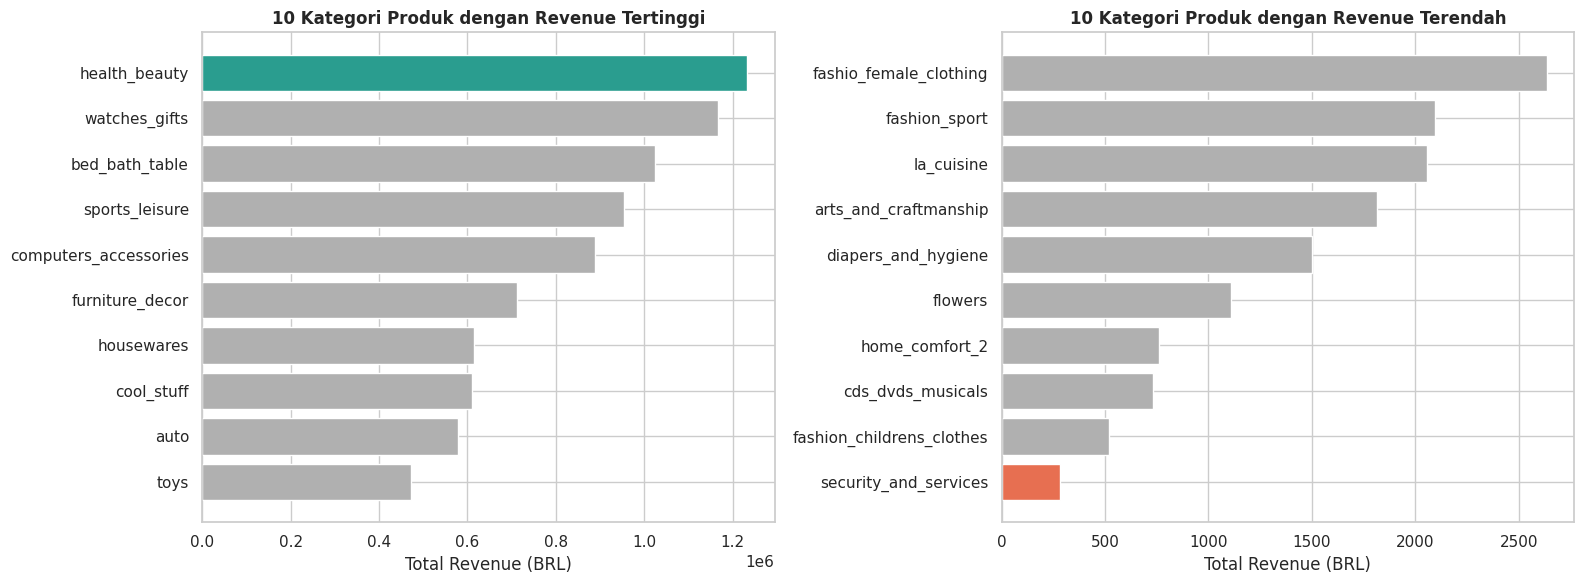

In [18]:
top10 = category_agg["revenue"].head(10)
bottom10 = category_agg["revenue"].tail(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# warna seragam (netral) untuk semua bar, kategori dengan nilai tertinggi/terendah disorot warna aksen
colors_top = [COLOR_HIGH if v == top10.max() else COLOR_NEUTRAL for v in top10.values]
colors_bottom = [COLOR_LOW if v == bottom10.min() else COLOR_NEUTRAL for v in bottom10.values]

axes[0].barh(top10.index[::-1], top10.values[::-1], color=colors_top[::-1])
axes[0].set_title("10 Kategori Produk dengan Revenue Tertinggi", fontweight="bold")
axes[0].set_xlabel("Total Revenue (BRL)")

axes[1].barh(bottom10.index[::-1], bottom10.values[::-1], color=colors_bottom[::-1])
axes[1].set_title("10 Kategori Produk dengan Revenue Terendah", fontweight="bold")
axes[1].set_xlabel("Total Revenue (BRL)")

plt.tight_layout()
plt.show()

### Pertanyaan 2: Bagaimana waktu pengiriman per provinsi dan hubungannya dengan review score?

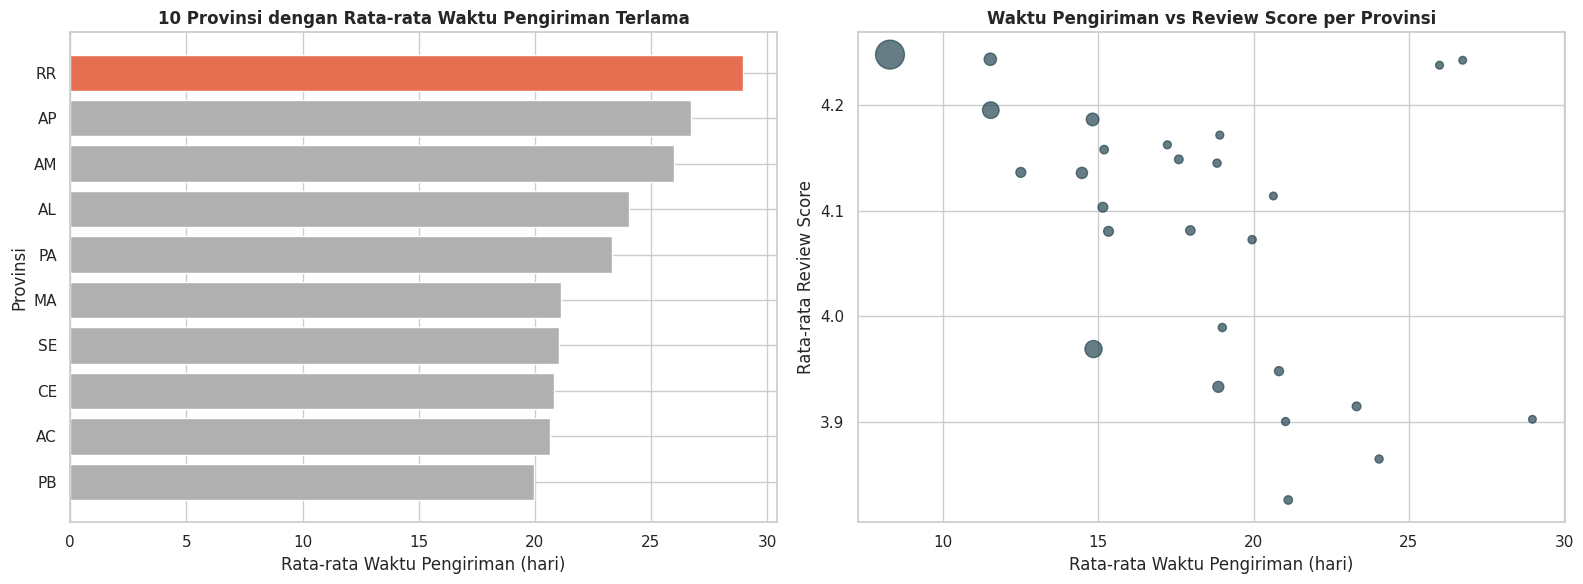

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_state = state_summary.head(10)
colors_state = [COLOR_LOW if v == top_state["avg_delivery_days"].max() else COLOR_NEUTRAL
                for v in top_state["avg_delivery_days"].values]
axes[0].barh(top_state.index[::-1], top_state["avg_delivery_days"].values[::-1], color=colors_state[::-1])
axes[0].set_title("10 Provinsi dengan Rata-rata Waktu Pengiriman Terlama", fontweight="bold")
axes[0].set_xlabel("Rata-rata Waktu Pengiriman (hari)")
axes[0].set_ylabel("Provinsi")

axes[1].scatter(state_summary["avg_delivery_days"], state_summary["avg_review_score"],
                s=state_summary["jumlah_order"] / state_summary["jumlah_order"].max() * 400 + 30,
                color=COLOR_HIGHLIGHT, alpha=0.7)
axes[1].set_title("Waktu Pengiriman vs Review Score per Provinsi", fontweight="bold")
axes[1].set_xlabel("Rata-rata Waktu Pengiriman (hari)")
axes[1].set_ylabel("Rata-rata Review Score")

plt.tight_layout()
plt.show()

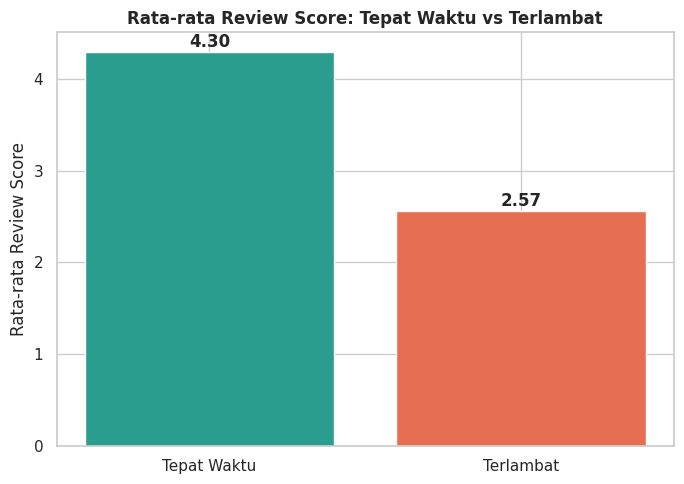

In [20]:
fig, ax = plt.subplots(figsize=(7, 5))
colors_late = [COLOR_LOW, COLOR_HIGH]  # False=tepat waktu, True=terlambat -> urutkan index dulu
review_by_late_sorted = review_by_late.sort_index()  # False, True
labels = ["Tepat Waktu", "Terlambat"]
ax.bar(labels, review_by_late_sorted.values, color=[COLOR_HIGH, COLOR_LOW])
ax.set_title("Rata-rata Review Score: Tepat Waktu vs Terlambat", fontweight="bold")
ax.set_ylabel("Rata-rata Review Score")
for i, v in enumerate(review_by_late_sorted.values):
    ax.text(i, v + 0.05, f"{v:.2f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- **Pertanyaan 1** terjawab dengan data: kategori `health_beauty` adalah penyumbang revenue tertinggi dengan total BRL 1.233.131,72 (9,33% dari total revenue BRL 13.221.498,11), diikuti `watches_gifts` (BRL 1.166.176,98; 8,82%) dan `bed_bath_table` (BRL 1.023.434,76; 7,74%). Sebaliknya, `security_and_services` adalah kontributor terendah dengan hanya BRL 283,29 (2 unit terjual) — kategori kecil ini kandidat evaluasi apakah masih layak dipertahankan dalam katalog.
- **Pertanyaan 2** terjawab: rata-rata waktu pengiriman bervariasi tajam antar provinsi, dari 8,3 hari (SP) hingga 28,98 hari (RR) — selisih lebih dari 3,5 kali lipat. Order yang terlambat dari estimasi (8,11% dari seluruh order) memiliki rata-rata review score hanya 2,57, jauh di bawah order tepat waktu (4,29) — gap 1,72 poin ini menjadi bukti kuat bahwa keterlambatan pengiriman adalah pendorong utama ketidakpuasan pelanggan.

## Analisis Lanjutan (Opsional)

**Tujuan Analisis Lanjutan — RFM Analysis (tanpa algoritma machine learning):**
Analisis ini bertujuan mengelompokkan pelanggan berdasarkan perilaku transaksi mereka menggunakan tiga dimensi:
- **Recency**: jumlah hari sejak transaksi terakhir pelanggan (dihitung dari tanggal snapshot, yaitu satu hari setelah transaksi terakhir pada dataset).
- **Frequency**: jumlah order unik yang pernah dilakukan pelanggan.
- **Monetary**: total nilai pembayaran yang pernah dikeluarkan pelanggan.

Segmentasi dilakukan dengan *manual binning* (`pd.qcut`, kuartil) pada tiap dimensi lalu digabung dengan aturan bisnis sederhana — bukan menggunakan algoritma machine learning seperti K-Means. Analisis ini menggunakan `orders_summary_df` (level order, bukan level item) agar `monetary` tidak terhitung berulang pada order multi-item.

In [21]:
rfm_df = orders_summary_df[orders_summary_df["order_status"] == "delivered"].groupby("customer_unique_id").agg(
    last_purchase=("order_purchase_timestamp", "max"),
    frequency=("order_id", "nunique"),
    monetary=("payment_value", "sum")
).reset_index()

snapshot_date = orders_summary_df.loc[orders_summary_df["order_status"] == "delivered", "order_purchase_timestamp"].max() + pd.Timedelta(days=1)
rfm_df["recency"] = (snapshot_date - rfm_df["last_purchase"]).dt.days

rfm_df["R"] = pd.qcut(rfm_df["recency"], 4, labels=[4, 3, 2, 1]).astype(int)
rfm_df["F"] = pd.qcut(rfm_df["frequency"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
rfm_df["M"] = pd.qcut(rfm_df["monetary"], 4, labels=[1, 2, 3, 4]).astype(int)

def assign_segment(row):
    if row["R"] >= 3 and row["F"] >= 3 and row["M"] >= 3:
        return "Champions"
    elif row["R"] >= 3 and row["F"] < 3:
        return "Potential Loyalist"
    elif row["R"] < 3 and row["F"] >= 3:
        return "At Risk"
    elif row["R"] <= 2 and row["F"] <= 2 and row["M"] <= 2:
        return "Hibernating/Lost"
    else:
        return "Need Attention"

rfm_df["segment"] = rfm_df.apply(assign_segment, axis=1)

total_customer = len(rfm_df)
total_monetary = rfm_df["monetary"].sum()
segment_summary = rfm_df.groupby("segment").agg(
    jumlah_pelanggan=("customer_unique_id", "count"),
    avg_recency=("recency", "mean"),
    avg_frequency=("frequency", "mean"),
    avg_monetary=("monetary", "mean"),
    total_monetary=("monetary", "sum")
).sort_values("jumlah_pelanggan", ascending=False)
segment_summary["pct_pelanggan"] = segment_summary["jumlah_pelanggan"] / total_customer * 100
segment_summary["pct_revenue"] = segment_summary["total_monetary"] / total_monetary * 100

print(f"Total pelanggan unik (delivered): {total_customer:,}")
print(segment_summary.round(2))

Total pelanggan unik (delivered): 93,358
                    jumlah_pelanggan  avg_recency  avg_frequency  \
segment                                                            
Potential Loyalist             23356       112.05           1.00   
At Risk                        23188       364.11           1.06   
Need Attention                 22412       238.06           1.01   
Champions                      12291       112.62           1.13   
Hibernating/Lost               12111       366.13           1.00   

                    avg_monetary  total_monetary  pct_pelanggan  pct_revenue  
segment                                                                       
Potential Loyalist        160.98      3759926.56          25.02        24.38  
At Risk                   166.44      3859325.15          24.84        25.02  
Need Attention            164.65      3690032.42          24.01        23.93  
Champions                 271.83      3341110.98          13.17        21.66  
Hibernat

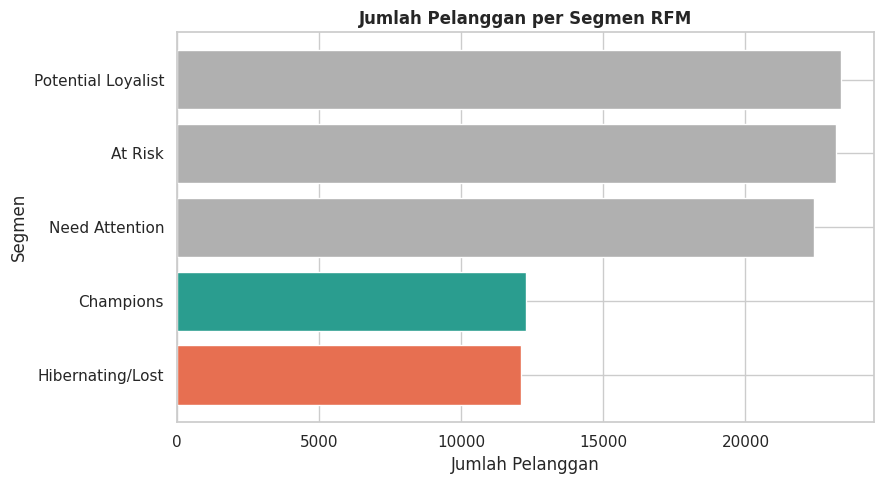

In [22]:
fig, ax = plt.subplots(figsize=(9, 5))
seg_order = segment_summary.index
colors_seg = [COLOR_HIGH if s == "Champions" else COLOR_LOW if s == "Hibernating/Lost" else COLOR_NEUTRAL
              for s in seg_order]
ax.barh(seg_order[::-1], segment_summary["jumlah_pelanggan"].values[::-1], color=colors_seg[::-1])
ax.set_title("Jumlah Pelanggan per Segmen RFM", fontweight="bold")
ax.set_xlabel("Jumlah Pelanggan")
ax.set_ylabel("Segmen")
plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- Dari 93.358 pelanggan unik, segmen `Potential Loyalist` (23.356 pelanggan; 25,02%) dan `At Risk` (23.188 pelanggan; 24,84%) adalah dua segmen terbesar — bersama-sama hampir separuh basis pelanggan.
- Segmen `Champions` hanya 13,17% dari total pelanggan namun menyumbang 21,66% dari total revenue, sementara `Hibernating/Lost` (12,97% pelanggan) hanya menyumbang 5,01% revenue dengan rata-rata recency 366 hari (lebih dari setahun tidak bertransaksi) — menunjukkan nilai pelanggan sangat timpang antar segmen.
- Segmen `At Risk` memiliki rata-rata recency 364 hari meski frekuensi/monetary historisnya cukup baik, artinya mereka pernah menjadi pelanggan bernilai namun berisiko tinggi churn — kandidat utama kampanye reaktivasi karena potensi nilainya masih besar (25,02% dari total revenue historis).

## Conclusion & Recommendation

**Conclusion Pertanyaan Bisnis 1 — Kategori produk dengan kontribusi revenue tertinggi & terendah**

Selama periode data 2016–2018, kategori `health_beauty` menunjukkan revenue tertinggi dengan kontribusi sebesar **BRL 1.233.131,72 (9,33% dari total revenue BRL 13.221.498,11)** dari 9.465 unit terjual, diikuti `watches_gifts` (BRL 1.166.176,98; 8,82%; 5.859 unit) dan `bed_bath_table` (BRL 1.023.434,76; 7,74%; 10.953 unit). Secara tren, penjualan cukup terkonsentrasi: lima kategori teratas menyumbang **±39,83%** dari seluruh revenue, sementara **46 dari 72 kategori** (lebih dari separuh jumlah kategori) masing-masing hanya menyumbang **kurang dari 1%** revenue, termasuk kategori dengan revenue terendah yaitu `security_and_services` (BRL 283,29 dari 2 unit) dan `fashion_childrens_clothes` (BRL 519,95 dari 7 unit). Hal ini menunjukkan bahwa mesin pertumbuhan platform bertumpu pada segelintir kategori unggulan, sementara puluhan kategori *long-tail* kontribusinya sangat kecil. Berdasarkan insight tersebut, tim bisnis dapat memprioritaskan anggaran stok dan promosi pada 5 kategori teratas untuk menjaga momentum revenue, sekaligus mengevaluasi apakah kategori *long-tail* dengan kontribusi <1% (seperti `security_and_services`) masih layak dipertahankan dalam katalog atau perlu strategi bundling untuk meningkatkan penjualannya.

**Conclusion Pertanyaan Bisnis 2 — Waktu pengiriman antar provinsi dan hubungannya dengan review score**

Rata-rata waktu pengiriman bervariasi tajam antar provinsi, mulai dari **8,3 hari di SP** (provinsi dengan volume order terbesar, 40.501 order) hingga **28,98 hari di RR** — selisih lebih dari 3,5 kali lipat, dengan korelasi negatif sebesar **-0,45** antara rata-rata waktu pengiriman dan rata-rata review score di level provinsi. Polanya konsisten: provinsi-provinsi di luar wilayah Tenggara (RR, AP, AM, AL, PA — semuanya di atas 23 hari) secara umum memiliki waktu pengiriman jauh lebih lama dibanding provinsi padat penduduk seperti SP, PR, dan MG (di bawah 12 hari). Analisis lebih lanjut menemukan bahwa **8,11% dari seluruh order delivered diterima melewati estimasi (terlambat)**, dan order yang terlambat ini memiliki rata-rata review score hanya **2,57**, jauh di bawah order yang tepat waktu (**4,29**) — gap sebesar **1,72 poin**. Ini adalah bukti kuat bahwa keterlambatan pengiriman, bukan sekadar lama pengiriman itu sendiri, adalah pendorong utama ketidakpuasan pelanggan. Berdasarkan temuan ini, tim logistik disarankan memprioritaskan penambahan mitra ekspedisi/gudang regional di provinsi-provinsi dengan waktu pengiriman >20 hari, serta menjadikan pengurangan angka keterlambatan (dari 8,11%) sebagai KPI utama karena dampaknya terhadap review score jauh lebih besar daripada sekadar mempercepat rata-rata waktu kirim.

**Conclusion Pertanyaan Bisnis 3 (RFM) — Segmentasi pelanggan**

Dari **93.358 pelanggan unik**, pelanggan terbagi menjadi lima segmen dengan komposisi: `Potential Loyalist` 25,02% (23.356 pelanggan), `At Risk` 24,84% (23.188 pelanggan), `Need Attention` 24,01% (22.412 pelanggan), `Champions` 13,17% (12.291 pelanggan), dan `Hibernating/Lost` 12,97% (12.111 pelanggan). Meski jumlahnya paling sedikit, segmen `Champions` menyumbang **21,66% dari total revenue historis**, sedangkan `Hibernating/Lost` yang jumlahnya serupa hanya menyumbang **5,01% revenue** dengan rata-rata recency 366 hari (lebih dari setahun tidak bertransaksi) — menunjukkan nilai pelanggan antar segmen sangat timpang. Segmen `At Risk` patut mendapat perhatian khusus: meski rata-rata recency-nya tinggi (364 hari), segmen ini secara historis menyumbang **25,02% dari total revenue**, nilai historis tertinggi di antara semua segmen — mengindikasikan mereka pernah menjadi pelanggan bernilai namun berisiko churn. Berdasarkan insight tersebut, tim CRM disarankan memprioritaskan kampanye reaktivasi (voucher/diskon personal) untuk segmen `At Risk` karena potensi nilai historisnya paling besar di antara segmen berisiko, sementara segmen `Champions` cukup dipertahankan lewat program loyalitas agar tidak berpindah ke kompetitor.

**Rekomendasi Action Item:**
- Prioritaskan alokasi anggaran stok & promosi pada 5 kategori dengan kontribusi revenue tertinggi (`health_beauty`, `watches_gifts`, `bed_bath_table`, `sports_leisure`, `computers_accessories`) yang bersama-sama menyumbang ±40% revenue, sekaligus evaluasi kelayakan 46 kategori *long-tail* (kontribusi <1%) untuk strategi bundling atau penghapusan katalog.
- Jadikan penurunan tingkat keterlambatan pengiriman (saat ini 8,11%) sebagai KPI utama tim logistik, dengan prioritas penambahan mitra ekspedisi/gudang regional di provinsi RR, AP, AM, AL, dan PA (waktu pengiriman >23 hari), karena gap review score antara order tepat waktu vs terlambat mencapai 1,72 poin.
- Jalankan kampanye reaktivasi bertarget pada segmen `At Risk` (24,84% pelanggan, menyumbang 25,02% revenue historis tertinggi) sebagai prioritas utama retensi, karena nilai historisnya besar namun berisiko churn tinggi (rata-rata recency 364 hari).